In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pyro
import pyro.distributions as dist
import scipy.io as sio
import torch
import torch.nn as nn
from pyro.infer import MCMC, NUTS, Predictive
from pyro.infer.autoguide import AutoLowRankMultivariateNormal
from pyro.nn import PyroModule, PyroSample
from pyro.optim import Adam
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader

from src.dataset import ESNDataset, construct_dataset, partition_dataset
from src.methods import ESNMCMC, ESNQR, CheckLoss, ESNVariational
from src.models import MLP, SSVS, BayesianModel, BayesianNeuralNetwork
from src.reservoir import Reservoir
from src.visualization import plot_probabilistic_forecast, plot_functional_connectivity

/Users/giacomogasparotto/POD/Bayesian-Inference-in-High-Dimensional-Reservoir-Dynamics-for-Neural-Time-Series/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Synthetic

# Real

In [3]:
# Load the MAT file for training and validation
rest1_file = sio.loadmat("./data/100307.REST1.LR.SchaeferS.ptseries.mat")
rest2_file = sio.loadmat("./data/100307.REST2.LR.SchaeferS.ptseries.mat")
data_rest1 = torch.from_numpy(rest1_file["tseries"]).float().t()
data_rest2 = torch.from_numpy(rest2_file["tseries"]).float().t()

In [4]:
mu1 = torch.mean(data_rest1, dim=0)
std1 = torch.std(data_rest1, dim=0)
mu2 = torch.mean(data_rest2, dim=0)
std2 = torch.std(data_rest2, dim=0)

data_rest1 = (data_rest1 - mu1) / std1
data_rest2 = (data_rest2 - mu2) / std2

## Create the Reservoir

In [5]:
num_neurons_real = 30
num_features_real = data_rest1.shape[1]
reservoir_real = Reservoir(
    input_features=num_features_real, num_neurons=num_neurons_real
)

## Generate the $(s,x)$ dataset

In [6]:
burnin_steps = 50
states_rest1 = torch.zeros((data_rest1.shape[0] - 1, num_neurons_real))
states_rest2 = torch.zeros((data_rest2.shape[0] - 1, num_neurons_real))

for i, x in enumerate(data_rest1[:-1]):
    states_rest1[i, :] = reservoir_real(x)

reservoir_real.reset_state()

for i, x in enumerate(data_rest2[:-1]):
    states_rest2[i, :] = reservoir_real(x)

dataset_rest1 = ESNDataset(
    states_rest1[burnin_steps:], data_rest1[burnin_steps:], mu1, std1
)
dataset_rest2 = ESNDataset(
    states_rest2[burnin_steps:], data_rest2[burnin_steps:], mu2, std2
)

In [7]:
train_set, cal_set, test_set = partition_dataset([dataset_rest1, dataset_rest2])

In [8]:
# move datasets to gpu
train_set = train_set.to(device)
cal_set = cal_set.to(device)
test_set = test_set.to(device)

## MCMC

In [9]:
mcmc_model_real = BayesianModel(
    in_features=num_neurons_real, out_features=num_features_real
).to(device)

In [10]:
esn_mcmc = ESNMCMC(mcmc_model_real)

In [11]:
# mcmc hyperparameters
warmup_steps = 150
num_samples = 100
num_chains = 5
mp_context = "spawn"

esn_mcmc.run(
    train_set,
    warmup_steps=warmup_steps,
    num_samples=num_samples,
    num_chains=num_chains,
    mp_context=mp_context,
)

Warmup [1]:   0%|          | 0/250 [00:00, ?it/s]





Warmup [1]:   0%|          | 1/250 [00:02,  2.04s/it, step size=1.40e-02, acc. prob=1.000]





Warmup [1]:   2%|▏         | 5/250 [00:02,  3.08it/s, step size=9.77e-03, acc. prob=0.800]



Warmup [1]:   3%|▎         | 8/250 [00:02,  5.27it/s, step size=2.25e-03, acc. prob=0.742]







Warmup [1]:   5%|▍         | 12/250 [00:02,  8.79it/s, step size=1.27e-02, acc. prob=0.807]








Warmup [1]:   7%|▋         | 17/250 [00:02, 11.30it/s, step size=4.55e-03, acc. prob=0.785]


Warmup [1]:   8%|▊         | 20/250 [00:03,  9.12it/s, step size=8.29e-03, acc. prob=0.797]


Warmup [1]:   9%|▉         | 22/250 [00:04,  5.32it/s, step size=1.95e-03, acc. prob=0.775]

Warmup [1]:  10%|▉         | 24/250 [00:05,  3.93it/s, step size=3.40e-03, acc. prob=0.785]



Warmup [1]:  10%|█         | 26/250 [00:06,  3.28it/s, step size=2.64e-03, acc. prob=0.782]



Warmup [1]:  11%|█         | 27/250 [00:06,  2.90it/s, step size=4.37e-03, acc. prob=0

In [12]:
y_pred = esn_mcmc.predict(test_set)
y_pred = y_pred.cpu()

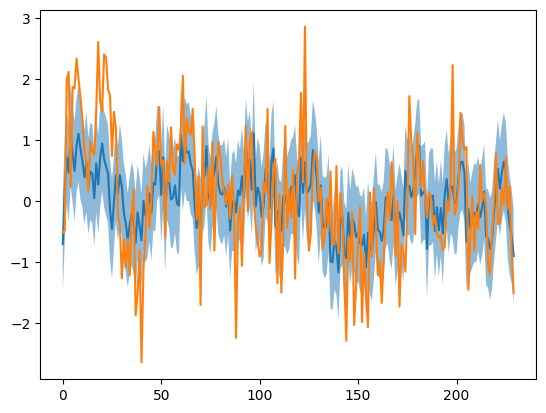

In [13]:
mean = torch.mean(y_pred[:, :, 0], dim=0)
std = torch.std(y_pred[:, :, 0], dim=0)
plt.plot(mean)
plt.fill_between(torch.arange(mean.shape[0]), mean - std, mean + std, alpha=0.5)
plt.plot(test_set.x.cpu()[:, 0])

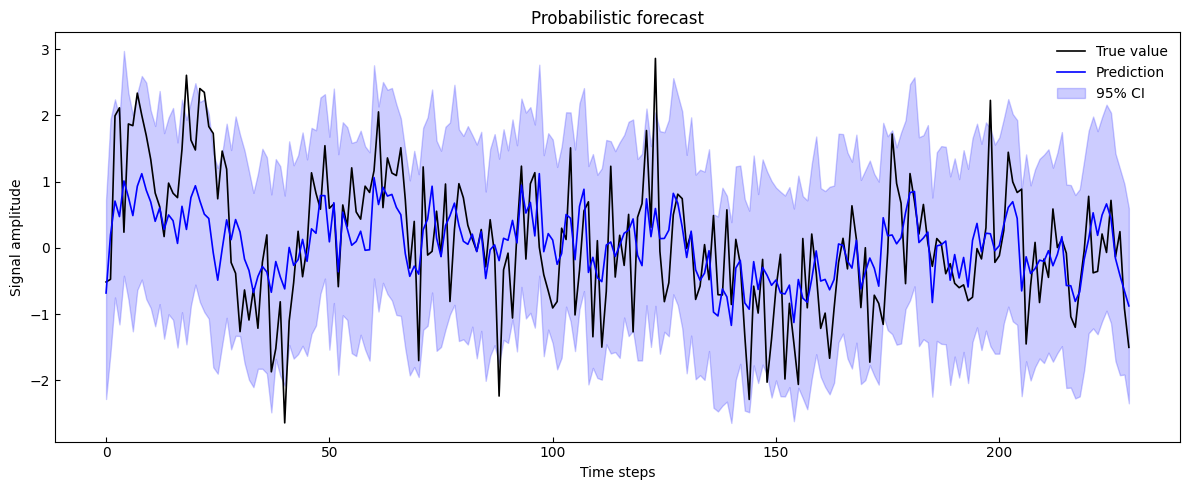

In [14]:
# Switch to numpy for plotting
y_pred_np = y_pred.numpy()
y_true_np = test_set.x.cpu().numpy()

# Extract mean and CI bounds
y_pred_mean = np.median(y_pred_np, axis=0)
y_lower = np.quantile(y_pred_np, 0.025, axis=0)
y_upper = np.quantile(y_pred_np, 0.975, axis=0)

# Plot the time series
plot_probabilistic_forecast(
    y_true=y_true_np[:, 0], 
    y_pred=y_pred_mean[:, 0], 
    y_lower=y_lower[:, 0], 
    y_upper=y_upper[:, 0]
)

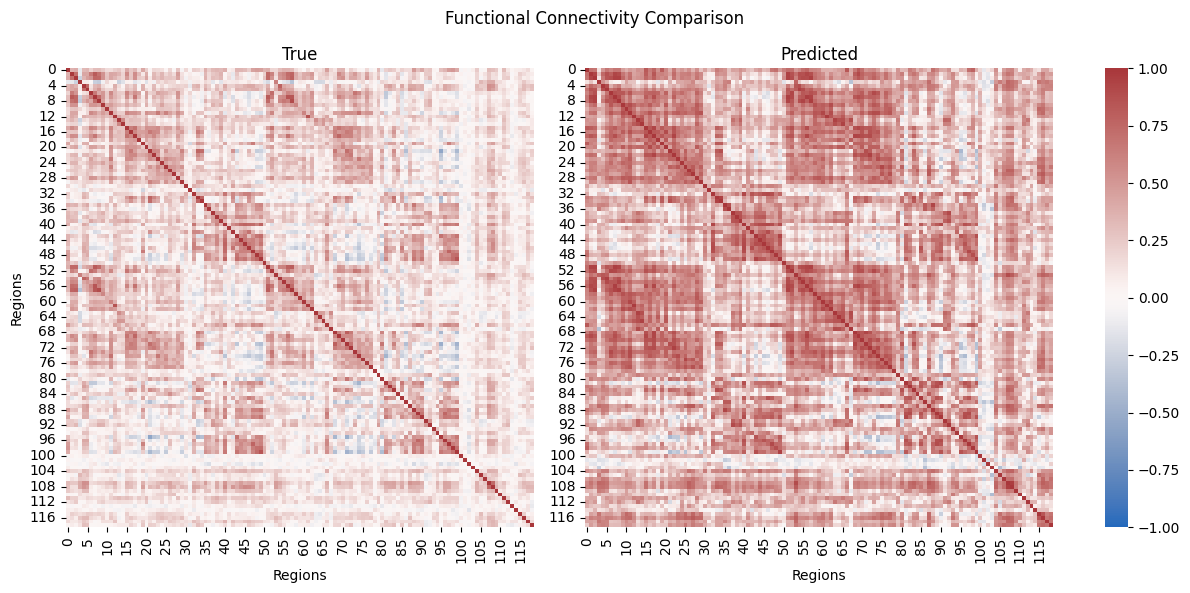

In [15]:
# Functional connectivity plot
plot_functional_connectivity(
    y_true_multi=y_true_np, 
    y_pred_multi=y_pred_mean
)

## MCMC with PCA

In [16]:
n_components = num_neurons_real // 2
pca = PCA(n_components)

In [17]:
# move datasets to cpu
train_set = train_set.to(torch.device("cpu"))
cal_set = cal_set.to(torch.device("cpu"))
test_set = test_set.to(torch.device("cpu"))

In [18]:
# fit pca
pca = pca.fit(train_set.states.numpy())

In [19]:
# apply pca to the sets
train_pca_set = ESNDataset(
    states=torch.tensor(pca.transform(train_set.states.numpy())),
    x=train_set.x,
    mu=train_set.mu,
    std=train_set.mu,
    device=device,
)
cal_pca_set = ESNDataset(
    states=torch.tensor(pca.transform(cal_set.states.numpy())),
    x=cal_set.x,
    mu=cal_set.mu,
    std=cal_set.mu,
    device=device,
)
test_pca_set = ESNDataset(
    states=torch.tensor(pca.transform(test_set.states.numpy())),
    x=test_set.x,
    mu=test_set.mu,
    std=test_set.mu,
    device=device,
)

In [20]:
mcmc_pca_model_real = BayesianModel(
    in_features=n_components, out_features=num_features_real
).to(device)

In [21]:
esn_mcmc = ESNMCMC(mcmc_pca_model_real)

In [22]:
# mcmc hyperparameters
warmup_steps = 150
num_samples = 100
num_chains = 5
mp_context = "spawn"

esn_mcmc.run(
    train_pca_set,
    warmup_steps=warmup_steps,
    num_samples=num_samples,
    num_chains=num_chains,
    mp_context=mp_context,
)

Warmup [1]:   0%|          | 0/250 [00:00, ?it/s]











Warmup [1]:   0%|          | 1/250 [00:02,  2.56s/it, step size=1.40e-02, acc. prob=1.000]


Warmup [1]:   2%|▏         | 4/250 [00:02,  1.89it/s, step size=5.51e-03, acc. prob=0.750]


Warmup [1]:   2%|▏         | 6/250 [00:02,  3.05it/s, step size=1.80e-02, acc. prob=0.833]


Warmup [1]:   3%|▎         | 8/250 [00:03,  4.29it/s, step size=2.78e-03, acc. prob=0.750]



Warmup [1]:   4%|▍         | 10/250 [00:03,  5.72it/s, step size=9.77e-03, acc. prob=0.800]





Warmup [1]:   5%|▌         | 13/250 [00:03,  8.68it/s, step size=1.34e-02, acc. prob=0.808]


Warmup [1]:   6%|▌         | 15/250 [00:03,  9.60it/s, step size=2.07e-03, acc. prob=0.767]








Warmup [1]:   7%|▋         | 17/250 [00:04,  4.50it/s, step size=5.36e-03, acc. prob=0.788]




Warmup [1]:   8%|▊         | 19/250 [00:04,  4.40it/s, step size=3.47e-03, acc. prob=0.782]






Warmup [1]:   8%|▊         | 20/250 [00:05,  3.76it/s, step size=6.20e-03, acc. p

In [23]:
y_pred = esn_mcmc.predict(test_pca_set)
y_pred = y_pred.cpu()

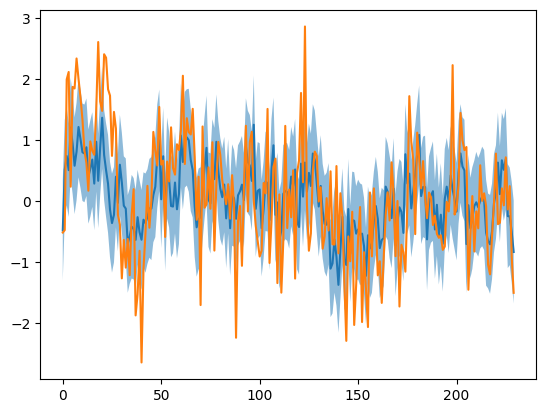

In [24]:
mean = torch.mean(y_pred[:, :, 0], dim=0)
std = torch.std(y_pred[:, :, 0], dim=0)
plt.plot(mean)
plt.fill_between(torch.arange(mean.shape[0]), mean - std, mean + std, alpha=0.5)
plt.plot(test_set.x.cpu()[:, 0])

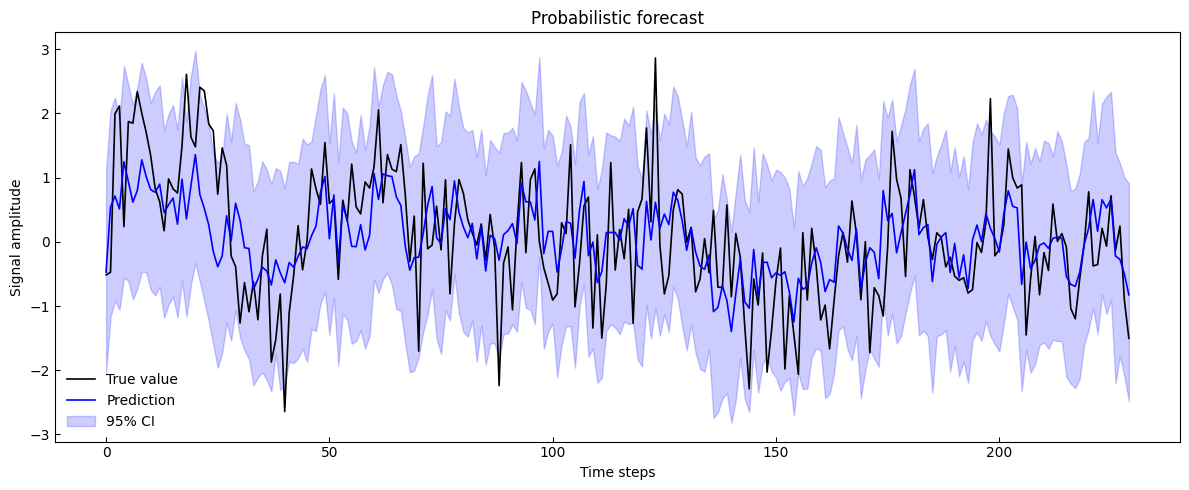

In [25]:
# Switch to numpy for plotting
y_pred_np = y_pred.numpy()
y_true_np = test_set.x.cpu().numpy()

# Extract mean and CI bounds
y_pred_mean = np.median(y_pred_np, axis=0)
y_lower = np.quantile(y_pred_np, 0.025, axis=0)
y_upper = np.quantile(y_pred_np, 0.975, axis=0)

# Time series plot
plot_probabilistic_forecast(
    y_true=y_true_np[:, 0], 
    y_pred=y_pred_mean[:, 0], 
    y_lower=y_lower[:, 0], 
    y_upper=y_upper[:, 0]
)

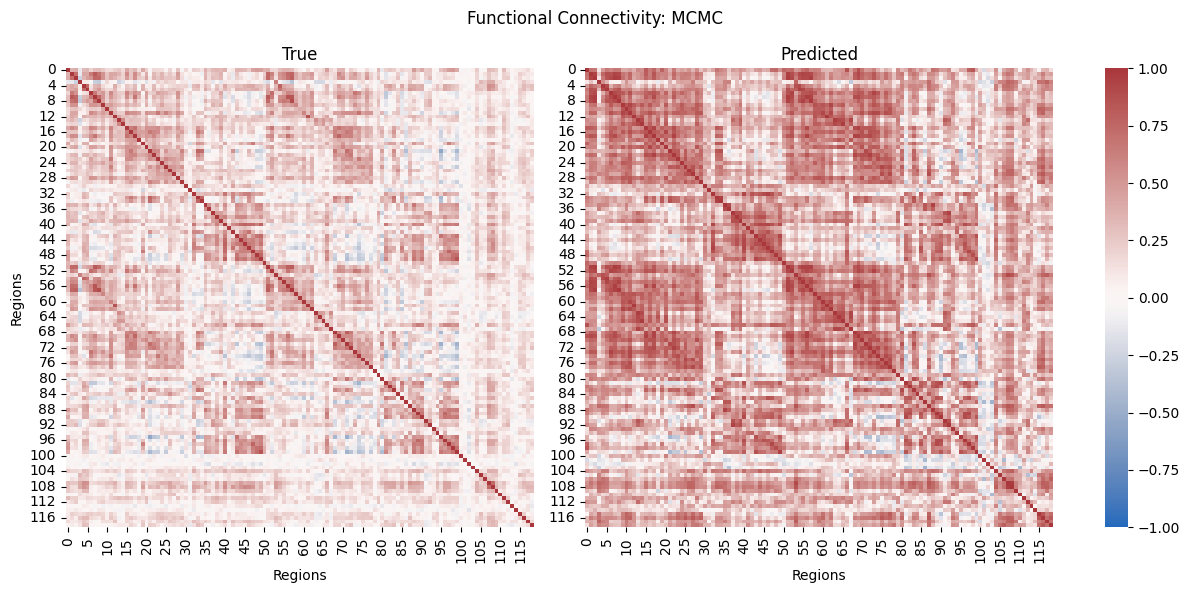

In [ ]:
# Functional connectivity plot
plot_functional_connectivity(
    y_true_multi=y_true_np, 
    y_pred_multi=y_pred_mean
)

## SVI

In [27]:
# move datasets to gpu
train_set = train_set.to(device)
cal_set = cal_set.to(device)
test_set = test_set.to(device)

In [28]:
svi_model_real = BayesianModel(
    in_features=num_neurons_real, out_features=num_features_real
).to(device)

In [29]:
# Setup Optimizer
LR = 0.0001
EPOCHS = 100

optimizer = Adam({"lr": LR})

In [30]:
# PYRO GUIDE

RANK = int(np.sqrt(num_neurons_real))  # Rank for the Multivariate Normal
guide = AutoLowRankMultivariateNormal(svi_model_real, rank=RANK)

In [31]:
esn_var_real = ESNVariational(
    svi_model_real,
    guide,
    optimizer,
)

Training Pyro ESN:   2%|▏         | 2/100 [00:01<00:47,  2.04it/s, Loss=20422.6546]

Epoch 0 | Total ELBO Loss: 21458.3297


Training Pyro ESN: 100%|██████████| 100/100 [00:10<00:00,  9.28it/s, Loss=8571.0735]


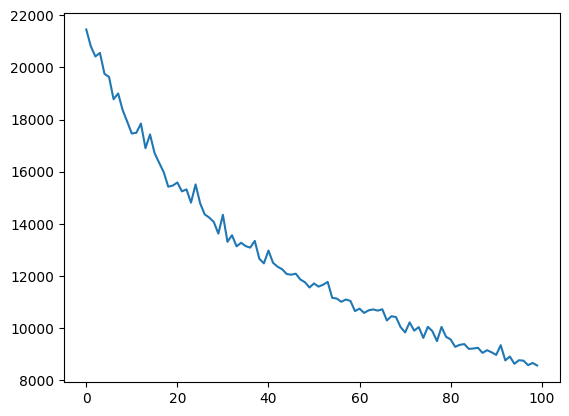

In [32]:
loss_history = esn_var_real.train(train_set, EPOCHS, batch_size=64, shuffle=True)
plt.plot(loss_history)
plt.show()

In [33]:
y_pred = esn_var_real.predict(test_set)
y_pred = y_pred.cpu()

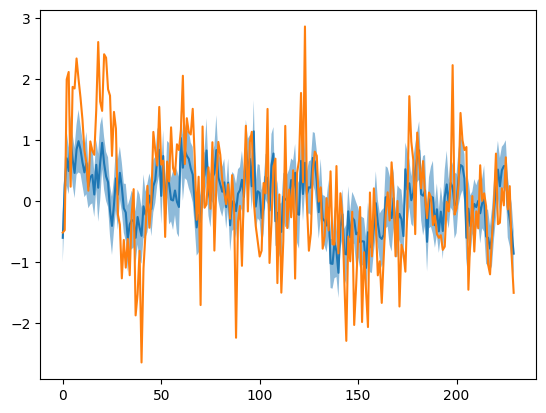

In [34]:
mean = torch.mean(y_pred[:, :, 0], dim=0)
std = torch.std(y_pred[:, :, 0], dim=0)
plt.plot(mean)
plt.fill_between(torch.arange(mean.shape[0]), mean - std, mean + std, alpha=0.5)
plt.plot(test_set.x.cpu()[:, 0])

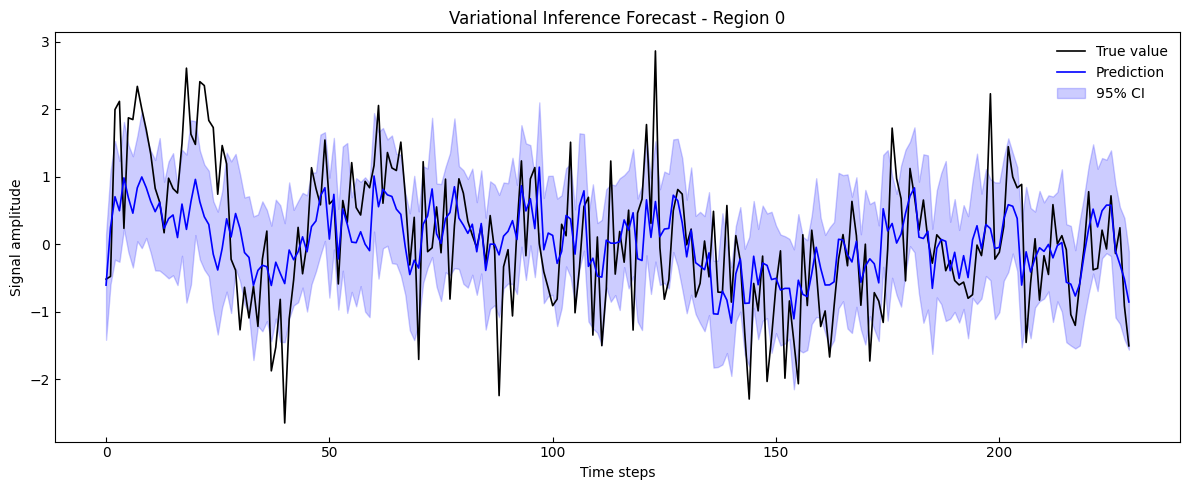

In [ ]:
# Switch to numpy for plotting
y_pred_np = y_pred.numpy()
y_true_np = test_set.x.cpu().numpy()

# Extract mean and CI bounds
y_pred_mean = np.median(y_pred_np, axis=0)
y_lower = np.quantile(y_pred_np, 0.025, axis=0)
y_upper = np.quantile(y_pred_np, 0.975, axis=0)

# Time series plot
plot_probabilistic_forecast(
    y_true=y_true_np[:, 0], 
    y_pred=y_pred_mean[:, 0], 
    y_lower=y_lower[:, 0], 
    y_upper=y_upper[:, 0]
)

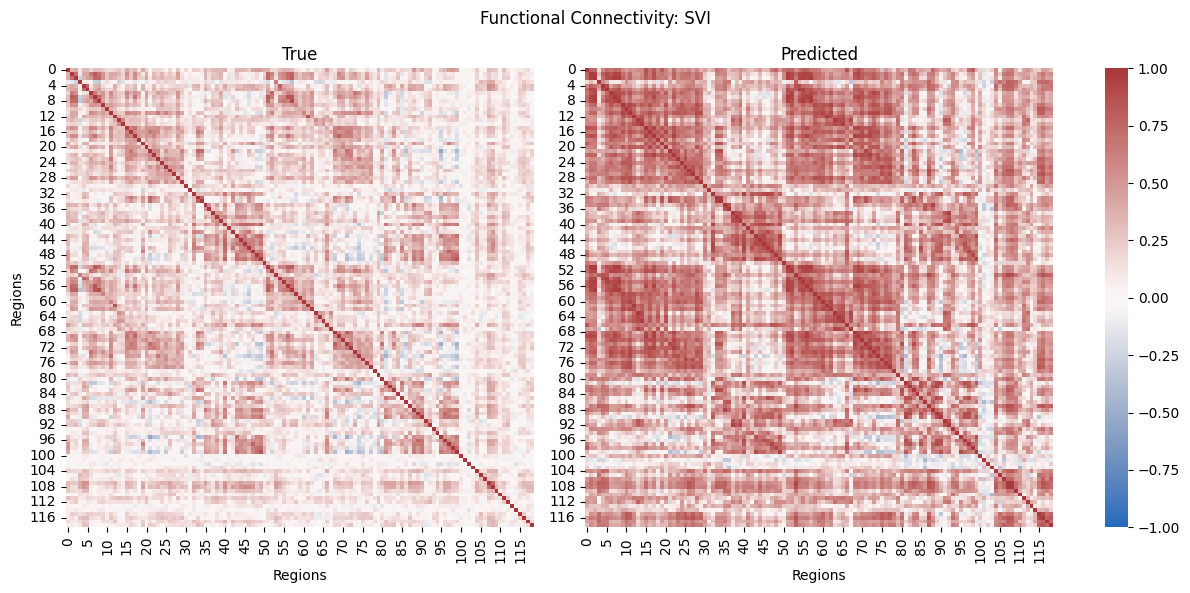

In [ ]:
# Functional connectivity plot
plot_functional_connectivity(
    y_true_multi=y_true_np, 
    y_pred_multi=y_pred_mean
)

## QR

In [37]:
taus = [0.025, 0.25, 0.5, 0.75, 0.975]
# Calculate the exact output size needed (e.g., 119 * 5 = 595)
num_quantiles = len(taus)
out_features = num_features_real * num_quantiles

# Update the linspace to target out_features
num_layers = 3
layer_dims = [
    int(layer_size)
    for layer_size in np.linspace(num_neurons_real, out_features, num_layers)
]

# Instantiate the model with the correct dimensions
qr_model_real = MLP(layer_dims, nn.Tanh()).to(device)

# Re-create your loss function and optimizer here...
loss_fn = CheckLoss(taus)
optimizer = torch.optim.Adam(qr_model_real.parameters(), lr=0.001)

# Re-instantiate the wrapper
esn_qr = ESNQR(qr_model_real, optimizer, loss_fn)

Training ESN:   2%|▎         | 5/200 [00:00<00:08, 22.95it/s, Loss=51.6427]

Epoch 0 | Total Loss: 59.6188


Training ESN:  52%|█████▏    | 104/200 [00:04<00:03, 26.09it/s, Loss=24.7272]

Epoch 100 | Total Loss: 24.7415


Training ESN: 100%|██████████| 200/200 [00:07<00:00, 25.57it/s, Loss=24.3864]


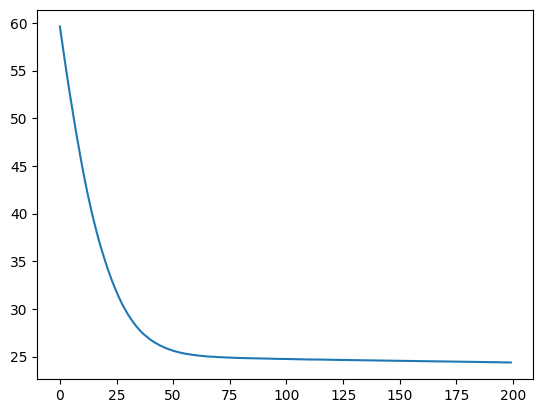

In [38]:
EPOCHS = 200
loss_history = esn_qr.train(train_set, EPOCHS, batch_size=64, shuffle=True)
plt.plot(loss_history)
plt.show()

In [39]:
y_pred = esn_qr.predict(test_set)
y_pred = y_pred.detach().cpu()
y_pred.shape

torch.Size([230, 5, 119])

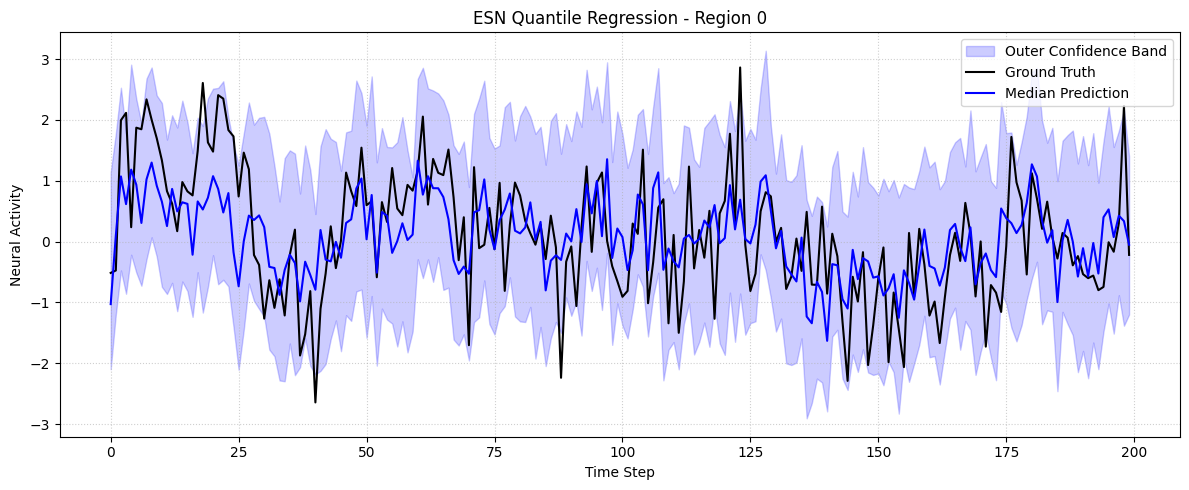

In [40]:
"""
plt.plot(test_set.x[0].cpu())
plt.plot(y_pred[0])
plt.show()
"""
# 1. Convert everything to pure NumPy arrays
y_pred_np = y_pred.numpy()
y_true_np = test_set.x.detach().cpu().numpy()

# 2. Setup plotting parameters
region_idx = 0  # Choose which of the 119 regions to plot (0 to 118)
time_steps = 200  # Plot the first 200 time steps so the chart is readable

# 3. Un-scale the data to original values (Highly Recommended)
mu_val = test_set.mu[region_idx].item()
std_val = test_set.std[region_idx].item()

y_true_region = y_true_np[:time_steps, region_idx]
y_pred_region = y_pred_np[:time_steps, :, region_idx]

# 4. Plotting
plt.figure(figsize=(12, 5))

# Assuming your 5 quantiles are symmetric (e.g., [0.1, 0.3, 0.5, 0.7, 0.9])
# Index 0 = lowest quantile, Index 4 = highest quantile, Index 2 = median

plt.fill_between(
    np.arange(time_steps),
    y_pred_region[:, 0],  # Lower bound
    y_pred_region[:, 4],  # Upper bound
    color="blue",
    alpha=0.2,
    label="Outer Confidence Band",
)

# Plot the Ground Truth
plt.plot(y_true_region, color="black", label="Ground Truth", linewidth=1.5)

# Plot the Median Prediction (50th percentile)
plt.plot(y_pred_region[:, 2], color="blue", linestyle="-", label="Median Prediction")

plt.title(f"ESN Quantile Regression - Region {region_idx}")
plt.xlabel("Time Step")
plt.ylabel("Neural Activity")
plt.legend(loc="upper right")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

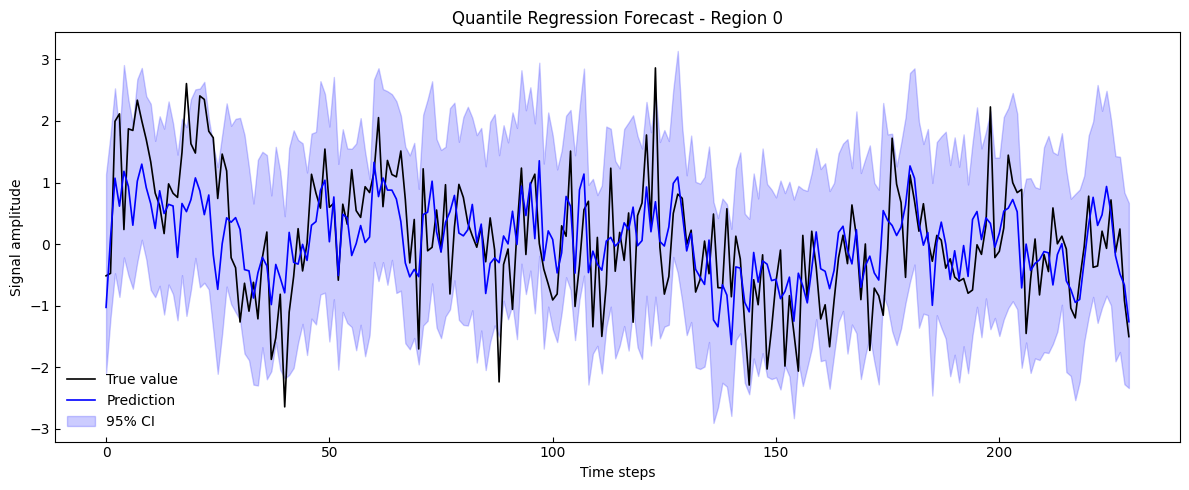

In [ ]:
# Switch to numpy for plotting
y_pred_np = y_pred.numpy()               
y_true_np = test_set.x.cpu().numpy()     

# Extract mean and CI bounds
y_lower = y_pred_np[:, 0, :]     
y_pred_mean = y_pred_np[:, 2, :]  
y_upper = y_pred_np[:, 4, :]       

# Time series plot
plot_probabilistic_forecast(
    y_true=y_true_np[:, 0], 
    y_pred=y_pred_mean[:, 0], 
    y_lower=y_lower[:, 0], 
    y_upper=y_upper[:, 0]
)

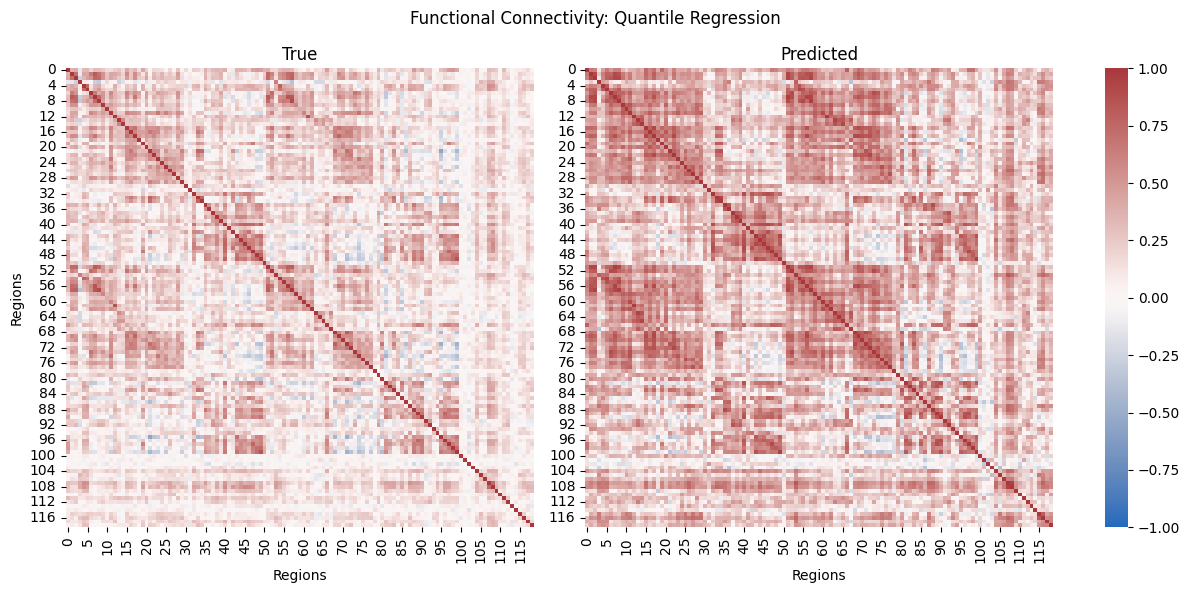

In [ ]:
# Functional connectivity plot
plot_functional_connectivity(
    y_true_multi=y_true_np, 
    y_pred_multi=y_pred_mean
)

## SVSS

In [43]:
ssvs_model_real = SSVS(num_neurons_real, num_features_real).to(device)

In [44]:
esn_mcmc = ESNMCMC(ssvs_model_real)

In [45]:
# mcmc hyperparameters
warmup_steps = 150
num_samples = 100
num_chains = 1
mp_context = "spawn"

esn_mcmc.run(
    train_set,
    warmup_steps=warmup_steps,
    num_samples=num_samples,
    num_chains=num_chains,
    mp_context=mp_context,
)

Sample: 100%|██████████| 250/250 [08:07,  1.95s/it, step size=4.06e-03, acc. prob=0.562]


In [46]:
y_pred = esn_mcmc.predict(test_set)
y_pred = y_pred.cpu()

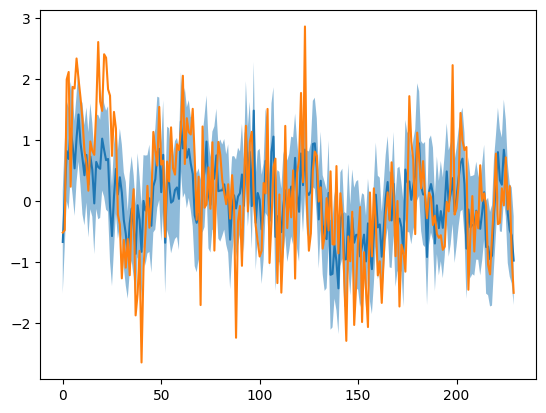

In [47]:
mean = torch.mean(y_pred[:, :, 0], dim=0)
std = torch.std(y_pred[:, :, 0], dim=0)
plt.plot(mean)
plt.fill_between(torch.arange(mean.shape[0]), mean - std, mean + std, alpha=0.5)
plt.plot(test_set.x.cpu()[:, 0])

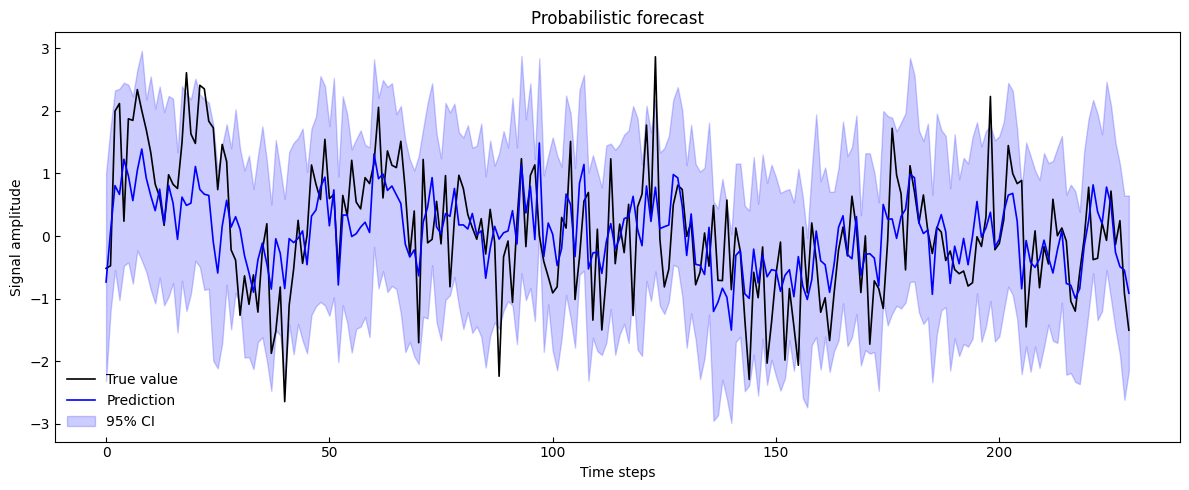

In [48]:
# Switch to numpy for plotting
y_pred_np = y_pred.numpy()
y_true_np = test_set.x.cpu().numpy()

# Extract mean and CI bounds
y_pred_mean = np.median(y_pred_np, axis=0)
y_lower = np.quantile(y_pred_np, 0.025, axis=0)
y_upper = np.quantile(y_pred_np, 0.975, axis=0)

# Time series plot
plot_probabilistic_forecast(
    y_true=y_true_np[:, 0], 
    y_pred=y_pred_mean[:, 0], 
    y_lower=y_lower[:, 0], 
    y_upper=y_upper[:, 0]
)

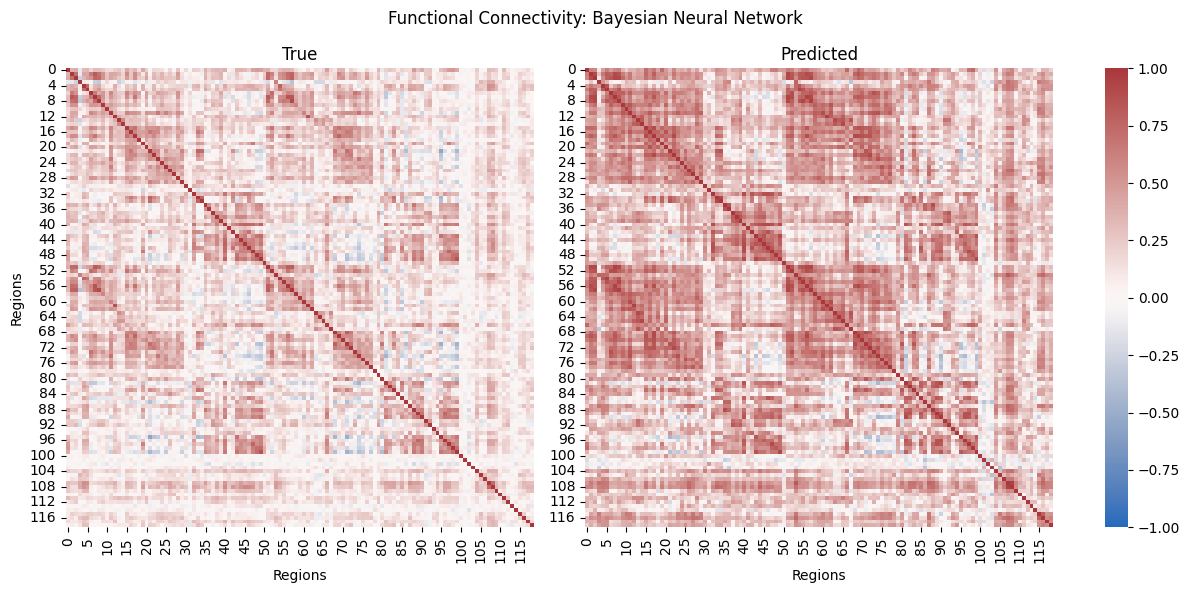

In [ ]:
# Functional connectivity plot
plot_functional_connectivity(
    y_true_multi=y_true_np, 
    y_pred_multi=y_pred_mean
)

## Bayesian Neural Network

In [50]:
num_layers = 3
layer_sizes = [
    int(layer_size)
    for layer_size in np.linspace(num_neurons_real, num_features_real, num_layers)
]
activation = nn.ELU()
nn_model_real = BayesianNeuralNetwork(layer_sizes, activation).to(device)

In [51]:
esn_mcmc = ESNMCMC(nn_model_real)

In [52]:
# mcmc hyperparameters
warmup_steps = 150
num_samples = 20
num_chains = 5
mp_context = "spawn"

esn_mcmc.run(
    train_set,
    warmup_steps=warmup_steps,
    num_samples=num_samples,
    num_chains=num_chains,
    mp_context=mp_context,
)

Warmup [1]:   0%|          | 0/170 [00:00, ?it/s]





Warmup [1]:   1%|          | 1/170 [00:02,  2.60s/it, step size=1.76e-03, acc. prob=1.000]





Warmup [1]:   3%|▎         | 5/170 [00:02,  2.38it/s, step size=1.22e-03, acc. prob=0.800]





Warmup [1]:   4%|▍         | 7/170 [00:02,  3.47it/s, step size=4.24e-03, acc. prob=0.857]





Warmup [1]:   5%|▌         | 9/170 [00:03,  4.63it/s, step size=1.53e-02, acc. prob=0.889]

Warmup [1]:   6%|▋         | 11/170 [00:03,  6.18it/s, step size=2.45e-02, acc. prob=0.886]















Warmup [1]:   9%|▉         | 15/170 [00:03,  7.72it/s, step size=3.18e-03, acc. prob=0.821]










Warmup [1]:  10%|█         | 17/170 [00:04,  5.13it/s, step size=1.47e-03, acc. prob=0.804]












Warmup [1]:  11%|█         | 19/170 [00:07,  1.84it/s, step size=4.88e-03, acc. prob=0.824]








Warmup [1]:  12%|█▏        | 21/170 [00:10,  1.22it/s, step size=8.09e-04, acc. prob=0.793]



Warmup [1]:  13%|█▎        | 22/170 [00:13,  1.18s/it, st

In [53]:
y_pred = esn_mcmc.predict(test_set)
y_pred = y_pred.cpu()

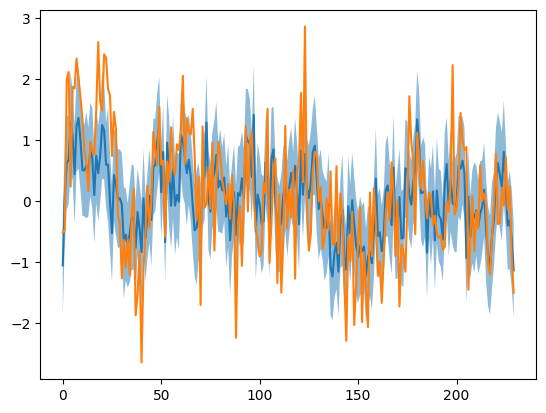

In [54]:
mean = torch.mean(y_pred[:, :, 0], dim=0)
std = torch.std(y_pred[:, :, 0], dim=0)
plt.plot(mean)
plt.fill_between(torch.arange(mean.shape[0]), mean - std, mean + std, alpha=0.5)
plt.plot(test_set.x.cpu()[:, 0])

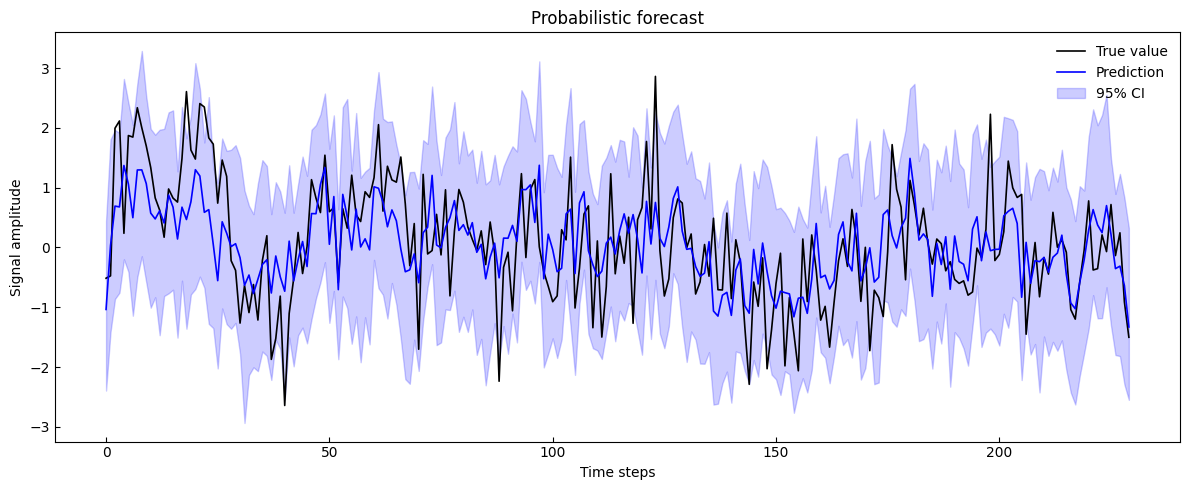

In [55]:
# Switch to numpy for plotting
y_pred_np = y_pred.numpy()
y_true_np = test_set.x.cpu().numpy()

# Extract mean and CI bounds
y_pred_mean = np.median(y_pred_np, axis=0)
y_lower = np.quantile(y_pred_np, 0.025, axis=0)
y_upper = np.quantile(y_pred_np, 0.975, axis=0)

# Time series plot
plot_probabilistic_forecast(
    y_true=y_true_np[:, 0], 
    y_pred=y_pred_mean[:, 0], 
    y_lower=y_lower[:, 0], 
    y_upper=y_upper[:, 0]
)

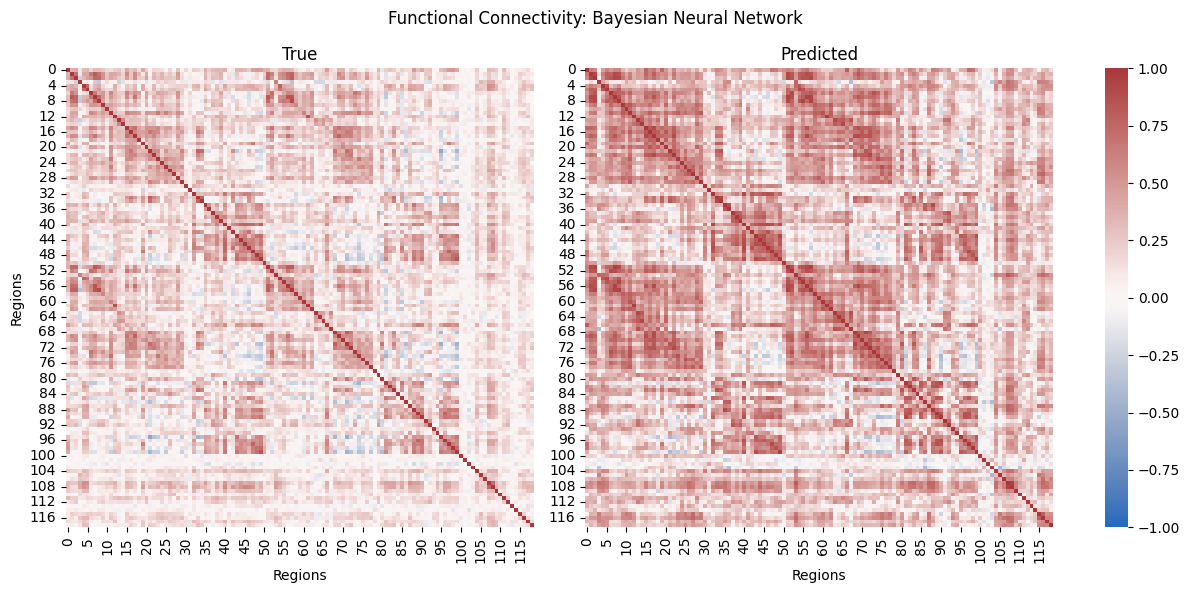

In [ ]:
# Functional connectivity plot
plot_functional_connectivity(
    y_true_multi=y_true_np, 
    y_pred_multi=y_pred_mean
)